# Experiment 1: Baseline U-Net for Ship Detection 
## Objective:
### The goal of this experiment is to establish a baseline model for ship segmentation using SAR imagery. This baseline will be used for comparison with later experiments that introduce architectural and training improvements



## 1. Libraries & Dependencies

#### This section imports all required libraries for the experiment.

* **PyTorch** for model building and training
* **NumPy** for numerical operations
* **Rasterio** for reading SAR `.tif` images
* **Albumentations** for data augmentation
* **Matplotlib** for visualization

#### These libraries form the foundation for data handling, model training, and evaluation.


In [1]:

# 1. Libraries & Dependencies

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import rasterio
import albumentations as A
import matplotlib.pyplot as plt

/dss/dsshome1/0F/di54cak/geo-oma-24/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration 
#### This section defines all experiment settings in a structured format.
#### Key parameters include:
* Dataset paths (images and masks)
* Batch size and validation split 
* Learning rate and number of epochs 
* Device selection (CPU/GPU)

#### Using a configuaration dictionary ensures reproducibility and makes it easier to modify hyperparameters across experiments.

In [2]:
import os
import torch

config = {
    "data": {
        "root": "/dss/dsshome1/0F/di54cak/geo-oma-24/temesghen_ship_detection_notebook/data/Patches",
        "img_dir": "images",
        "mask_dir": "masks",
        "batch_size": 8,
        "num_workers": 2,
        "val_split": 0.2,
    },
    "training": {
        "epochs": 50,
        "lr": 1e-3,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },
    "outputs": {
        "save_dir": "outputs"
    }
}

os.makedirs(config["outputs"]["save_dir"], exist_ok=True)
device = config["training"]["device"]
print("Using device:", device)

Using device: cpu


## 3. Dataset Class

#### This section defines a custom dataset for loading SAR images and corresponding masks.

**Key steps:**

* Reads VV and VH channels from `.tif` files
* Clips SAR values to reduce noise
* Normalizes values to a [0, 1] range
* Loads and normalizes ground truth masks
* Applies optional data augmentation

#### The dataset outputs:

* Input image tensor (2 channels: VV, VH)
* Ground truth segmentation mask

#### This class ensures efficient and consistent data loading during training.


In [3]:

# 3. Dataset Class (VV + VH only)

class ShipDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Read SAR image
        with rasterio.open(self.img_paths[idx]) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)
            img = np.stack([vv, vh], axis=-1)
            img = np.clip(img, -25, 10)
            img = (img + 25.0) / 35.0

        # Read mask
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.float32)
            if mask.max() > 0:
                mask = mask / mask.max()
            mask = np.expand_dims(mask, -1)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        img = torch.from_numpy(img).permute(2,0,1).float()
        mask = torch.from_numpy(mask).permute(2,0,1).float()

        return img, mask


## 4. Dataloaders

#### This section prepares the data for training and validation.

**Key steps:**

* Loads image and mask file paths
* Splits dataset into training and validation sets
* Applies augmentation only to training data
* Creates PyTorch DataLoaders

#### DataLoaders handle:

* Batching
* Shuffling (training only)
* Efficient data feeding into the model

#### This ensures smooth and scalable training.


In [4]:

# 4. Dataloaders

def get_dataloaders(cfg):
    img_dir = os.path.join(cfg["data"]["root"], cfg["data"]["img_dir"])
    mask_dir = os.path.join(cfg["data"]["root"], cfg["data"]["mask_dir"])

    imgs = sorted(glob.glob(os.path.join(img_dir, "*.tif")))
    masks = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

    split = int((1 - cfg["data"]["val_split"]) * len(imgs))
    train_imgs, val_imgs = imgs[:split], imgs[split:]
    train_masks, val_masks = masks[:split], masks[split:]

    train_tf = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.RandomBrightnessContrast(p=0.3)
    ])

    train_ds = ShipDataset(train_imgs, train_masks, train_tf)
    val_ds = ShipDataset(val_imgs, val_masks, None)

    train_loader = DataLoader(train_ds,
                              batch_size=cfg["data"]["batch_size"],
                              shuffle=True)

    val_loader = DataLoader(val_ds,
                            batch_size=cfg["data"]["batch_size"],
                            shuffle=False)

    return train_loader, val_loader


train_loader, val_loader = get_dataloaders(config)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 50
Val batches: 13


## 5. U-Net Model

#### This section defines the segmentation model.

**Architecture:**

* Encoder (downsampling path)
* Bottleneck (feature extraction)
* Decoder (upsampling path with skip connections)

**Key characteristics:**

* Input: 2 channels (VV, VH)
* Output: 1-channel binary mask
* Skip connections preserve spatial details

#### U-Net is widely used for segmentation tasks due to its ability to capture both global context and fine details.


In [5]:

# 5. U-Net Model

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=2, base=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up1 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.dec1 = DoubleConv(base*8, base*4)

        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.dec2 = DoubleConv(base*4, base*2)

        self.up3 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.dec3 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        u1 = self.up1(b)
        d1 = self.dec1(torch.cat([u1, e3], dim=1))

        u2 = self.up2(d1)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u3 = self.up3(d2)
        d3 = self.dec3(torch.cat([u3, e1], dim=1))

        return torch.sigmoid(self.out(d3))


model = UNet(in_channels=2).to(device)

## 6. Loss & Metrics

#### This section defines how the model is trained and evaluated.

**Loss Function:**

* Binary Cross-Entropy (BCE)

**Evaluation Metrics:**

* Dice Coefficient for overlap accuracy
* Intersection over Union (IoU) for segmentation quality

#### These metrics provide a more meaningful evaluation than loss alone, especially for segmentation tasks.


In [6]:

# 6. Loss & Metrics

bce = nn.BCELoss()

def dice_coef(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    return (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)

## 7. Training Loop

#### This section performs the model training process.

**Training Phase:**

* Forward pass
* Loss computation
* Backpropagation
* Weight updates

**Validation Phase:**

* Model evaluation without gradient updates
* Metric calculation

#### Metrics tracked:

* Loss
* Dice score
* IoU score

#### This loop runs for a fixed number of epochs (50), without early stopping.


In [ ]:

# 7. Training Loop

optimizer = optim.Adam(model.parameters(), lr=config["training"]["lr"])

train_loss_hist, val_loss_hist = [], []
train_dice_hist, val_dice_hist = [], []
train_iou_hist, val_iou_hist = [], []

for epoch in range(config["training"]["epochs"]):

    # Training 
    model.train()
    tl, td, ti = 0, 0, 0

    for img, mask in train_loader:
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)
        loss = bce(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tl += loss.item()
        td += dice_coef(pred, mask).item()
        ti += iou_score(pred, mask).item()

    # Validation 
    model.eval()
    vl, vd, vi = 0, 0, 0

    with torch.no_grad():
        for img, mask in val_loader:
            img = img.to(device)
            mask = mask.to(device)

            pred = model(img)
            loss = bce(pred, mask)

            vl += loss.item()
            vd += dice_coef(pred, mask).item()
            vi += iou_score(pred, mask).item()

    train_loss_hist.append(tl/len(train_loader))
    val_loss_hist.append(vl/len(val_loader))
    train_dice_hist.append(td/len(train_loader))
    val_dice_hist.append(vd/len(val_loader))
    train_iou_hist.append(ti/len(train_loader))
    val_iou_hist.append(vi/len(val_loader))

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss_hist[-1]:.4f}, "
          f"Val Loss={val_loss_hist[-1]:.4f}, "
          f"Train Dice={train_dice_hist[-1]:.4f}, "
          f"Val Dice={val_dice_hist[-1]:.4f}, "
          f"Train IoU={train_iou_hist[-1]:.4f}, "
          f"Val IoU={val_iou_hist[-1]:.4f}")

Epoch 1: Train Loss=0.3349, Val Loss=0.2196, Train Dice=0.1541, Val Dice=0.0000, Train IoU=0.0888, Val IoU=0.0000
Epoch 2: Train Loss=0.1820, Val Loss=0.1150, Train Dice=0.0887, Val Dice=0.0802, Train IoU=0.0502, Val IoU=0.0422
Epoch 3: Train Loss=0.1151, Val Loss=0.0811, Train Dice=0.1954, Val Dice=0.6079, Train IoU=0.1169, Val IoU=0.4453
Epoch 4: Train Loss=0.0819, Val Loss=0.0542, Train Dice=0.2880, Val Dice=0.7123, Train IoU=0.1746, Val IoU=0.5608
Epoch 5: Train Loss=0.0657, Val Loss=0.0491, Train Dice=0.2978, Val Dice=0.6974, Train IoU=0.1848, Val IoU=0.5396
Epoch 6: Train Loss=0.0566, Val Loss=0.0391, Train Dice=0.3391, Val Dice=0.7470, Train IoU=0.2102, Val IoU=0.6041
Epoch 7: Train Loss=0.0518, Val Loss=0.0383, Train Dice=0.3427, Val Dice=0.1556, Train IoU=0.2192, Val IoU=0.0879
Epoch 8: Train Loss=0.0489, Val Loss=0.0291, Train Dice=0.3527, Val Dice=0.6840, Train IoU=0.2216, Val IoU=0.5300
Epoch 9: Train Loss=0.0469, Val Loss=0.0264, Train Dice=0.3497, Val Dice=0.6393, Train I

## 8. Training Curves

#### This section visualizes model performance over epochs.

#### Graphs include:

* Loss curve (Train vs Validation)
* Dice score curve
* IoU score curve

#### These plots help identify:

* Learning progress
* Overfitting or underfitting
* Model stability

#### They are essential for understanding training behavior.


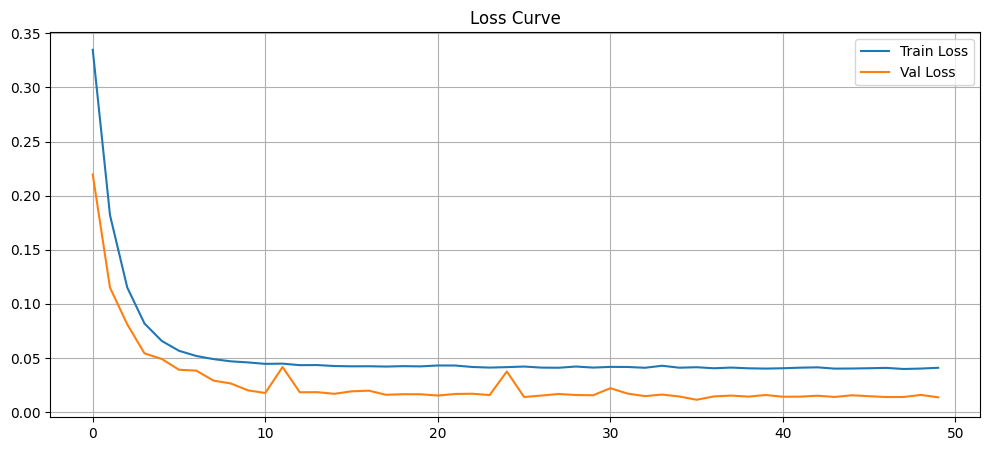

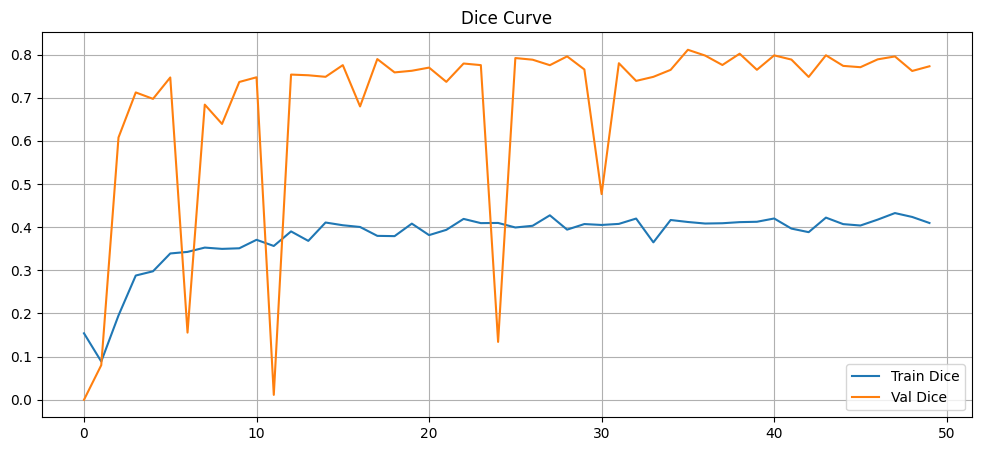

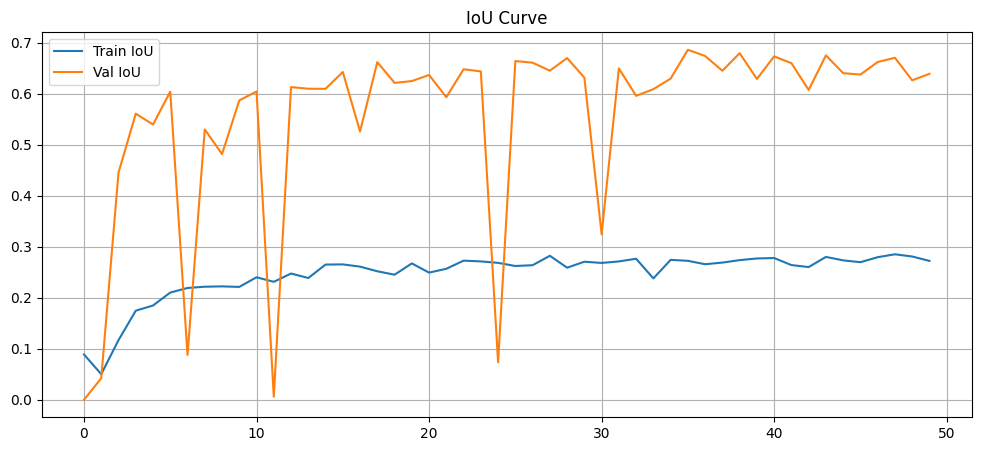

In [11]:
# 8. Plot Training Curves

plt.figure(figsize=(12,5))
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.legend()
plt.grid(True)
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(train_dice_hist,label="Train Dice")
plt.plot(val_dice_hist,label="Val Dice")
plt.legend()
plt.grid(True)
plt.title("Dice Curve")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(train_iou_hist,label="Train IoU")
plt.plot(val_iou_hist,label="Val IoU")
plt.legend()
plt.grid(True)
plt.title("IoU Curve")
plt.show()

# 10. Visualization of Predictions

#### Displays:

* Input channels (VV, VH)
* Ground truth
* Model prediction

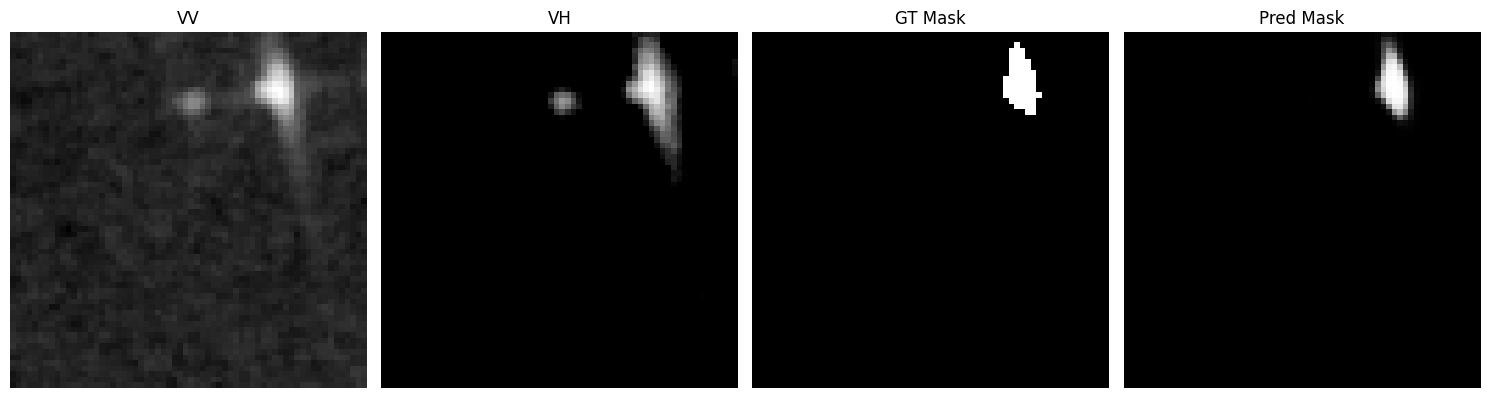

In [10]:

# 9. Visualize Predictions

img, mask = next(iter(val_loader))
img = img.to(device)
mask = mask.to(device)

with torch.no_grad():
    pred = model(img)

img = img.cpu()
mask = mask.cpu()
pred = pred.cpu()

fig, axs = plt.subplots(1,4, figsize=(15,5))

axs[0].imshow(img[0,0], cmap='gray')
axs[0].set_title("VV")

axs[1].imshow(img[0,1], cmap='gray')
axs[1].set_title("VH")

axs[2].imshow(mask[0,0], cmap='gray')
axs[2].set_title("GT Mask")

axs[3].imshow(pred[0,0], cmap='gray')
axs[3].set_title("Pred Mask")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()